In [1]:
import matplotlib.pyplot as plt # type: ignore
import torch #type: ignore
import torchvision #type: ignore
from src.CasiaWebface import CasiaWebface #type: ignore
from src.Detector import Detector #type: ignore

In [2]:
model = torchvision.models.resnet101(weights=torchvision.models.ResNet101_Weights.DEFAULT)
feature_extractor = torch.nn.Sequential(*(list(model.children())[:-1]))

In [3]:
torch.save(feature_extractor.state_dict(), './models/feature_extractor.pth')

In [4]:
model = None
feature_extractor = None

In [5]:
chechpoint = torch.load('./models/feature_extractor.pth', weights_only=True)
model = torchvision.models.resnet101()
feature_extractor = torch.nn.Sequential(*(list(model.children())[:-1]))
feature_extractor.load_state_dict(chechpoint)

<All keys matched successfully>

In [6]:
dataset = CasiaWebface(rec_path='./data/casia-webface/train.rec',
                       idx_path='./data/casia-webface/train.idx')
detector = Detector(model_path='./models/yolov8n-face.pt')


0: 640x640 1 face, 72.5ms
Speed: 72.8ms preprocess, 72.5ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


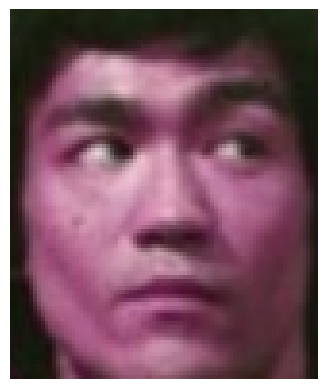


0: 640x640 1 face, 58.7ms
Speed: 2.9ms preprocess, 58.7ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
tensor([[[[0.1396]],

         [[0.1351]],

         [[0.1075]],

         ...,

         [[0.0968]],

         [[0.0750]],

         [[0.1404]]]], grad_fn=<MeanBackward1>)
torch.Size([1, 2048, 1, 1])


In [7]:
img, label = dataset[0]

detector.detect()
vis_img = detector(img)
plt.axis('off')
plt.imshow(vis_img)
plt.show()

detector.tensor()
img = detector(img)
img = img.unsqueeze(0)
features = feature_extractor(img)
print(features)
print(features.size())